In [1]:
# %pip install xgboost
# %pip install lightgbm
# %pip install catboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

## 1.전처리
### 1-1. 데이터 로드

In [3]:
# 1. 데이터 로드 (원본 데이터 경로 확인)
df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

# df.info()

df.head()

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723


### 1-2. 컬럼 삭제
#### 1-2-1. 삭제할 컬럼 내용 확인

In [4]:
# 1. 보험금 변동률
# 변수 이름 길어서 쓰기 귀찮.
PCT = 'premium_change_pct'  # 보험율 변화분
CP = 'current_premium'      # 올해 보험료
PLY = 'premium_last_year'   # 작년 보험료

# 작년보험율 * (1+보험률변화분)
# pd.concat( [df[PLY] * (1 + df[PCT]), df[CP]], axis=1)

# (올해보험료 - 작년보험료) / 작년보험료
pd.concat( [df[PCT], (df[CP]-df[PLY])/df[PLY]], axis=1)

,premium_change_pct,0
0,-0.0365,-0.043932
1,0.0479,0.070923
2,0.1184,0.126285
3,0.1502,0.125365
4,0.0161,-0.017785
...,...,...
49995,-0.0095,-0.030983
49996,0.0920,0.073481
49997,-0.0207,-0.003613
49998,0.0579,0.069665


#### 비교 결과
'premium_change_pct' 컬럼의 값과, (current_premium - premium_last_year)/premium_last_year의 값이 같지 않음.
보험 도메인의 특수성에 따라 단순히 값 비교로 따르기 힘듦.
* 단순히 작년 총액과 올해 총액을 비교한 것이 아니라 1년 치로 환산한 보험료를 기준으로 변동률 계산
* 세금이나 수수로 제외
* 이벤트 등올 인한 할인/할증 제외

premium_increase.ipynb 결과에 따르면 보험료 증감률이 굉장히 중요한데,
premium_change_pct(작년 대비 올해 보험료 증감률)와,
절대값인 금액이 중요할 수 있어 current_premium(올해 보험료) 특성은 존재.
premium_last_year(작년 보험료) 특성은 제거

In [5]:
# 2. 연체 횟수 정보와 연체 4회 이상 정보
s_above_4_yn = 'missed_payment_flag'  # 미납 플래그(연체 4회 이상 시 1)
s_w_count = 'late_payment_count_12m'  # 최근 12개월 내 연체횟수

# 연체 4회 이상 플래그가 1인 경우 12개월 내 연체횟수가 4회 이상인지 확인
df_1 = df[df[s_above_4_yn] == 1]
df_1[[s_above_4_yn, s_w_count]]

# 연체 4회 이상 플래그가 0인 경우 12개월 내 연체횟수가 4회 미만인지 확인
df_0 = df[df[s_above_4_yn] == 0]
df_0[[s_above_4_yn, s_w_count]]

,missed_payment_flag,late_payment_count_12m
0,0,0
1,0,0
2,0,0
3,0,2
4,0,0
...,...,...
49995,0,1
49996,0,1
49997,0,0
49998,0,0


#### 비교 결과
miss_payment_flag 컬럼 내용은 late_payment_count 내용에 포함이 되는 내용이라서 삭제.

In [6]:
# 3. 총 보장금액과 현재 연간 보험료와 보장 금액 대부 보험료비율
s_cover = 'coverage_amount'             # 총 보장금액
s_prm = 'current_premium'               # 현재 연간 보험료
s_ratio = 'premium_to_coverage_ratio'   # 보장금액대비 보험료 비율

# 데이터 프레임 분리
df_r = df[[s_cover, s_prm, s_ratio]]
print(df_r.head())

# 혹시 몰라 값 비교
df_r['cal_ratio'] = df[s_prm]/df[s_cover]
df_r['is_match'] = (df_r[s_ratio] - df_r['cal_ratio']) < 0.01

match_count = df_r['is_match'].sum()
match_count # 5만건
# => 모두 맞음. 그러면 컬럼 제거

   coverage_amount  current_premium  premium_to_coverage_ratio
0          8924.09          1013.47                   0.113565
1         43734.45          1126.90                   0.025767
2         23152.37           984.70                   0.042531
3         31806.95           373.61                   0.011746
4        302831.02           974.18                   0.003217


np.int64(50000)

#### 비교 결과
coverage_amount 특성은 current_premium 특성과 premium_to_coverage_ratio 특성에 포함된 특성이라 삭제.

current_premium 특성도 함께 삭제하려다가 위에서 삭제 안하기로 해서 삭제 안함.

In [7]:
# 4. 청구건수와 지급액 관련 데이터
claim = 'num_claims_12m'
a = 'num_approved_claims_12m'
r = 'num_rejected_claims_12m'
p = 'num_pending_claims_12m'
#s_t_claim = 'total_claim_amount_12m'

df_c = df
df_c = df_c[[claim, a, r, p]]
df_c['cal'] = df_c[a] + df_c[r] + df_c[p]
df_c['is_match'] = (df_c[claim] == df_c['cal'])
df_c['is_match'].sum()

np.int64(50000)

#### 1-2-2. 컬럼 삭제

In [12]:
# 아예 삭제할 컬럼
drop_cols = [
    'customer_id',             # 사용자 ID
	'region_name',             # 지역명
	'as_of_date',              # 기준일자
	'renewal_month',           # 갱신월
	'payment_frequency',       # 납입 주기
    'autopay_enabled',         # 자동 이체 여부
	'churn_type',              # 이탈 원인 분류
	'churn_flag',              # 이탈 여부
	'churn_probability_true',  # 실제 이탈 확률
	]

# 내용이 중복되는 컬럼
dupl_cols = [
    'age_band',                # 나이 밴디지(age 컬럼과 중복)
    'premium_last_year',       # 작년 보험료
    'missed_payment_flag',     # 'late_payment_count_12m'와 중복 4회 이상
    'coverage_amount',         #
    # 'current_premium',
    'num_approved_claims_12m',
    'num_rejected_claims_12m',
    'num_pending_claims_12m',
    ]

print('전체 컬럼 수:', len(df.columns))
print('삭제 컬럼 수:', len(drop_cols) + len(dupl_cols))

df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])
df_clean = df_clean.drop(columns=[col for col in dupl_cols if col in df_clean.columns])
print('남은 컬럼 수:', len(df_clean.columns))
df_clean.head()
df_clean.columns

전체 컬럼 수: 40
삭제 컬럼 수: 16
남은 컬럼 수: 24


Index(['age', 'marital_status', 'customer_tenure_months', 'multi_policy_flag',
       'num_policies', 'policy_type', 'current_premium', 'premium_change_pct',
       'num_price_increases_last_3y', 'premium_to_coverage_ratio',
       'late_payment_count_12m', 'payment_method_change_flag',
       'num_claims_12m', 'avg_claim_amount', 'total_claim_amount_12m',
       'total_payout_amount_12m', 'payout_ratio_12m',
       'avg_settlement_time_days', 'days_since_last_claim', 'num_contacts_12m',
       'complaint_flag', 'complaint_resolution_days', 'quote_requested_flag',
       'coverage_downgrade_flag'],
      dtype='str')

### 1-3. 범주형 컬럼 인코딩

In [17]:
df_cat = df_clean
# 범주형 컬럼
cat_cols = ['marital_status', 'policy_type']
# 인코딩 매핑정보를 담을 딕셔너리
encoding_map = {}

le = LabelEncoder()

for col in cat_cols:
    # 데이터 프레임에 실제 컬럼이 있는지 확인 후 변환
    if col in df_cat.columns:
        df_cat[col] = le.fit_transform(df_cat[col].astype(str))

        # {숫자: 원래이름} 형태로 저장
        encoding_map[col] = {int(i): label for i, label in enumerate(le.classes_)}
        print(f"[{col}] 변환 완료: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# 화면단에서 매핑된 카테고리 정보를 겟하기 위해서 json 파일로 저장.
import json
# JSON 파일로 저장 (나중에 화면단에서 불러오기 용이)
with open('encoding_map.json', 'w', encoding='utf-8') as f:
    json.dump(encoding_map, f, ensure_ascii=False, indent=4)
"""
파일 읽어오기 버전
# 파일 읽어오기
with open('encoding_map.json', 'r') as f:
    loaded_map = json.load(f)

# 만약 화면에 보여줄 데이터프레임이 'result_df'라면
# 숫자를 다시 문자로 복원 (화면 표시용)
display_df = result_df.copy()
for col, mapping in loaded_map.items():
    # JSON은 키가 문자열로 저장되므로 숫자로 변환하여 매핑
    display_df[col] = display_df[col].map({int(k): v for k, v in mapping.items()})
"""

df_cat[cat_cols].head()
df_cat.head()

[marital_status] 변환 완료: ['0', '1'] -> [0, 1]
[policy_type] 변환 완료: ['0', '1', '2', '3', '4'] -> [0, 1, 2, 3, 4]


,age,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,current_premium,premium_change_pct,num_price_increases_last_3y,premium_to_coverage_ratio,...,total_claim_amount_12m,total_payout_amount_12m,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag
0,24,0,128,1,4,0,1013.47,-0.0365,1,0.113565,...,0.0,0.0,0.75,7,1616,0,0,0,0,0
1,70,0,76,1,3,0,1126.90,0.0479,2,0.025767,...,0.0,0.0,0.75,15,1760,1,0,0,0,0
2,62,0,129,0,1,0,984.70,0.1184,1,0.042531,...,0.0,0.0,0.75,24,1581,1,0,0,0,0
3,47,1,104,0,1,0,373.61,0.1502,2,0.011746,...,0.0,0.0,0.75,17,1688,1,0,0,0,0
4,47,0,22,1,3,3,974.18,0.0161,1,0.003217,...,0.0,0.0,0.85,24,1592,1,0,0,0,0


### 1-4. 스케일링


In [22]:
# 요약 통계량 확인
outlier_summary = df_cat.describe()

# IQR 기반 이상치 개수 계산 함수
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

# 주요 컬럼별 이상치 개수 출력
for col in ['current_premium', 'total_claim_amount_12m', 'avg_claim_amount']:
    if col in df_cat.columns:
        print(f"{col}의 이상치 개수: {count_outliers(df_cat, col)}개")

for col in df_cat.columns:
    print(f"{col}의 이상치 개수: {count_outliers(df_cat, col)}개")

# 이상치의 개수가 이상한 값들이 있어서 확인이 필요한 것. => flag값
df['complaint_resolution_days'].value_counts()

current_premium의 이상치 개수: 618개
total_claim_amount_12m의 이상치 개수: 6683개
avg_claim_amount의 이상치 개수: 3749개
age의 이상치 개수: 0개
marital_status의 이상치 개수: 0개
customer_tenure_months의 이상치 개수: 0개
multi_policy_flag의 이상치 개수: 0개
num_policies의 이상치 개수: 5361개
policy_type의 이상치 개수: 0개
current_premium의 이상치 개수: 618개
premium_change_pct의 이상치 개수: 153개
num_price_increases_last_3y의 이상치 개수: 0개
premium_to_coverage_ratio의 이상치 개수: 1811개
late_payment_count_12m의 이상치 개수: 1364개
payment_method_change_flag의 이상치 개수: 7029개
num_claims_12m의 이상치 개수: 6683개
avg_claim_amount의 이상치 개수: 3749개
total_claim_amount_12m의 이상치 개수: 6683개
total_payout_amount_12m의 이상치 개수: 6683개
payout_ratio_12m의 이상치 개수: 474개
avg_settlement_time_days의 이상치 개수: 157개
days_since_last_claim의 이상치 개수: 0개
num_contacts_12m의 이상치 개수: 148개
complaint_flag의 이상치 개수: 2022개
complaint_resolution_days의 이상치 개수: 2022개
quote_requested_flag의 이상치 개수: 5424개
coverage_downgrade_flag의 이상치 개수: 4926개


complaint_resolution_days
0     47978
14      140
11      137
15      126
10      124
13      118
12      118
9       117
8       110
16      106
7        94
18       86
17       80
5        78
6        77
19       74
1        67
4        64
20       61
3        49
21       46
22       35
23       31
2        27
24       22
26       10
27       10
25        8
29        3
28        3
31        1
Name: count, dtype: int64

In [23]:
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def apply_custom_scaling(df):
    # 컬럼별로 적용할 변환기를 담을 리스트
    transformers = []

    for col in df.columns:
        if col in cat_cols:
            print(f"Skipping (Excluded): {col}")
            continue

        # 1. 컬럼명에 'amount'가 들어가는 경우 -> 로그 변환 (Log1p)
        if 'amount' in col.lower():
            # log1p는 log(1+x)로 0값이 있어도 에러가 나지 않습니다.
            log_transformer = Pipeline([
                ('log', FunctionTransformer(np.log1p)),
                ('std', StandardScaler()) # 로그 후 정규화 추가
            ])
            transformers.append((f'log_{col}', log_transformer, [col]))
            print(f"Applying Log Transformation to: {col}")

        # 2. 이상치가 있는 경우 (IQR 방식을 기준으로 판단) -> RobustScaler
        # 여기서는 간단히 IQR 1.5배 밖의 값이 하나라도 있으면 이상치로 간주합니다.
        else:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]

            if len(outliers) > 0:
                transformers.append((f'robust_{col}', RobustScaler(), [col]))
                print(f"Applying RobustScaler to: {col} (Outliers detected)")

            # 3. 그 외 일반적인 경우 -> StandardScaler
            else:
                transformers.append((f'std_{col}', StandardScaler(), [col]))
                print(f"Applying StandardScaler to: {col}")

    # ColumnTransformer를 이용해 한 번에 적용
    ct = ColumnTransformer(transformers, remainder='passthrough')
    return ct.fit_transform(df)

# 실행
scaled_data = apply_custom_scaling(df_cat)
scaled_df = pd.DataFrame(scaled_data, columns=df_cat.columns)

print("\n--- 스케일링 완료 데이터 ---")
scaled_df

Applying StandardScaler to: age
Skipping (Excluded): marital_status
Applying StandardScaler to: customer_tenure_months
Applying StandardScaler to: multi_policy_flag
Applying RobustScaler to: num_policies (Outliers detected)
Skipping (Excluded): policy_type
Applying RobustScaler to: current_premium (Outliers detected)
Applying RobustScaler to: premium_change_pct (Outliers detected)
Applying StandardScaler to: num_price_increases_last_3y
Applying RobustScaler to: premium_to_coverage_ratio (Outliers detected)
Applying RobustScaler to: late_payment_count_12m (Outliers detected)
Applying RobustScaler to: payment_method_change_flag (Outliers detected)
Applying RobustScaler to: num_claims_12m (Outliers detected)
Applying Log Transformation to: avg_claim_amount
Applying Log Transformation to: total_claim_amount_12m
Applying Log Transformation to: total_payout_amount_12m
Applying RobustScaler to: payout_ratio_12m (Outliers detected)
Applying RobustScaler to: avg_settlement_time_days (Outliers d

,age,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,current_premium,premium_change_pct,num_price_increases_last_3y,premium_to_coverage_ratio,...,total_claim_amount_12m,total_payout_amount_12m,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag
0,-1.397954,0.725985,1.462306,3.0,0.006419,-0.862131,-0.817340,3.620587,0.0,0.0,...,0.0,-1.000000,1.285868,-0.5,0.0,0.0,0.0,0.0,0.0,0.0
1,0.943703,-0.277205,1.462306,2.0,0.202409,-0.106535,0.403737,0.555205,0.0,0.0,...,0.0,-0.272727,1.573112,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.536458,0.745277,-0.683852,0.0,-0.043291,0.524620,-0.817340,1.140520,0.0,0.0,...,0.0,0.545455,1.216051,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.227125,0.262974,-0.683852,0.0,-1.099161,0.809311,0.403737,0.065689,2.0,0.0,...,0.0,-0.090909,1.429490,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.227125,-1.318979,1.462306,2.0,-0.061468,-0.391226,-0.817340,-0.232099,0.0,0.0,...,2.0,0.545455,1.237994,0.0,0.0,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.180119,-1.261102,-0.683852,0.0,0.142936,-0.620412,-0.817340,-0.189294,1.0,0.0,...,2.0,-0.363636,0.813112,0.5,0.0,0.0,0.0,0.0,1.0,3.0
49996,1.707287,-0.026407,-0.683852,0.0,3.162089,0.288272,1.624815,0.674138,1.0,0.0,...,1.0,0.727273,-0.459540,-0.5,0.0,0.0,0.0,0.0,0.0,1.0
49997,-1.194332,-0.161452,-0.683852,0.0,-0.482095,-0.720680,-0.817340,-0.284588,0.0,0.0,...,0.0,0.727273,-1.299330,2.0,0.0,0.0,0.0,0.0,1.0,2.0
49998,-0.634370,-0.682339,-0.683852,0.0,-0.853824,-0.017010,1.624815,-0.311154,0.0,0.0,...,0.0,0.545455,-0.924317,1.5,0.0,0.0,0.0,0.0,1.0,2.0


In [10]:
# def train_multi_classifiers():
#     """
#     다양한 분류 모델을 학습시키고 그 결과를 데이터 프레임으로 반환
#     :param df:
#     :return:
#     """
# 파생변수 생성 메소드
def create_features(X):
    """파생변수를 추가하고, 불필요한 컬럼을 삭제해 반환하는 함수"""
    X = X.copy()    # 원본 데이터 보존

    # 1. 청구 거절률
    if 'num_rejected_claims_12m' in X.columns and 'num_claims_12m' in X.columns:
            # 분모에 0 방지
            epsilon = 1e-8

            X['claim_rejection_rate'] = X['num_rejected_claims_12m'] / (X['num_claims_12m'] + epsilon)
    # 2. 보험료 급등 여부( 10% 초과 인상
    if 'premium_change_pct' in X.columns:
            X['is_premium_spiked'] = X['premium_change_pct'].apply(lambda x: 1 if x > 0.10 else 0)

    # 3. 적극적 이탈 징후 (견적 요청 또는 보장 축소)
    if 'quote_requested_flag' in X.columns and 'coverage_downgrade_flag' in X.columns:
        X['active_churn_signal'] = np.where(
            (X['quote_requested_flag'] == 1) | (X['coverage_downgrade_flag'] == 1), 1, 0
        )

    # 4. 계약당 평균 납입금
        if 'current_premium' in X.columns and 'num_policies' in X.columns:
            X['premium_per_policy'] = X['current_premium'] / X['num_policies']

    return X

In [24]:
X = scaled_df.copy()
y = df['churn_flag']

# 데이터 분류
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(40000, 24) (40000,) (10000, 24) (10000,)


## 2. 모델 학습
### 2-1. RandomForestClassifier

### 모델 평가 결과 ###
              precision    recall  f1-score   support

           0       0.84      0.72      0.78      6983
           1       0.51      0.68      0.58      3017

    accuracy                           0.71     10000
   macro avg       0.68      0.70      0.68     10000
weighted avg       0.74      0.71      0.72     10000

ROC-AUC Score: 0.7778


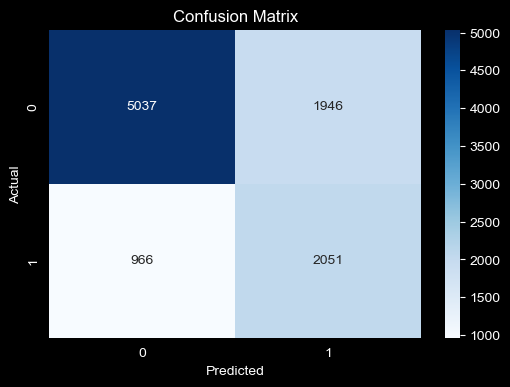

In [28]:
from sklearn.metrics import f1_score, roc_auc_score, recall_score
# from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
# 1. 모델 생성 및 학습
# n_estimators: 나무의 개수, max_depth: 나무의 깊이 (과적합 방지)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# 2. 예측 수행
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1] # ROC-AUC 계산을 위한 확률값

# 3. 결과 리포트 출력
print("### 모델 평가 결과 ###")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 6. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 모델에서 예측 확률(Probability) 가져오기
# [:, 1]은 '이탈할 확률(1)'만 가져오겠다는 뜻입니다.
y_probs = rf_clf.predict_proba(X_test)[:, 1]

def get_eval_by_threshold(y_test, y_probs, thresholds):
    result_list = []
    for threshold in thresholds:
        # 설정한 임계값보다 확률이 크면 1(이탈), 아니면 0
        preds = (y_probs >= threshold).astype(int)

        accuracy = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds)
        recall = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        result_list.append([threshold, accuracy, precision, recall, f1])

    # 보기 좋게 데이터프레임으로 변환
    columns = ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
    return pd.DataFrame(result_list, columns=columns)

# 0.3부터 0.5까지 0.05 단위로 테스트
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
eval_df = get_eval_by_threshold(y_test, y_probs, thresholds)

print("### 임계값 변화에 따른 성능 변화 ###")
print(eval_df)

### 임계값 변화에 따른 성능 변화 ###
   Threshold  Accuracy  Precision    Recall  F1-Score
0       0.30    0.4904   0.365819  0.939344  0.526570
1       0.35    0.5480   0.391793  0.901889  0.546276
2       0.40    0.6218   0.434199  0.836593  0.571687
3       0.45    0.6667   0.468094  0.768313  0.581754
4       0.50    0.7088   0.513135  0.679814  0.584830


### 2-1. XGBClassifier

In [30]:
# 1. 불균형 비율 계산 (약 2.31)
# 유지(0) 6983 / 이탈(1) 3017
ratio = 6983 / 3017

# 2. XGBoost 모델 생성 (xgb_clf)
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio,  # 불균형 데이터 처리를 위한 가중치
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. 모델 학습
xgb_clf.fit(X_train, y_train)

# 4. 예측 및 확률 추출
y_pred = xgb_clf.predict(X_test)
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# 5. 성능 평가 (F2 Score 포함)
print("### XGBoost 모델 평가 결과 ###")
print(classification_report(y_test, y_pred))

# F2 Score 따로 계산 (beta=2)
# f2 = fbeta_score(y_test, y_pred, beta=2)
auc = roc_auc_score(y_test, y_probs)

print(f"ROC-AUC Score: {auc:.4f}")
# print(f"F2 Score (Recall 강조): {f2:.4f}")

C:\Users\Playdata\miniconda3\envs\second_project_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:33:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### XGBoost 모델 평가 결과 ###
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      6983
           1       0.53      0.68      0.59      3017

    accuracy                           0.72     10000
   macro avg       0.68      0.71      0.69     10000
weighted avg       0.75      0.72      0.73     10000

ROC-AUC Score: 0.7823


## 1. 기존 가설 확인된 내용 미반영

## 2. 기존 가설 확인된 내용 반영
참고파일
1. claim.ipynb
2. 03_6_and_7
3. dependents
4. Lockin_analysis
5. premium_increase
6. SeonHo